based on cca_simulation2, I want to see if using cross validation i can obtain better weight estimates (more similar ot the gt weights) using less trials.

- My hyperparameter is the L2 regularization term
- My parameters are the time lag and the weights

In [1]:
from cca_simulation2_script import *

In [3]:
# ==== add below your helpers in cca_simulation2_script.py =====================

from dataclasses import dataclass
from typing import List, Tuple, Dict
import numpy as np
import pandas as pd
from cca_zoo.linear import rCCA
import matplotlib.pyplot as plt

# ---------------- ridge-CCA for 1-D Y (pupil) --------------------------------
def ridge_cca_wx_zoo(X: np.ndarray, y: np.ndarray, lam: float) -> np.ndarray:
    """
    Return EEG weights w_x for 1-D target y using ridge-regularized CCA.
    Tries cca-zoo rCCA;
    Assumes X and y are mean-centered (your concat_trials already z-scores y).
    """

    n = X.shape[0]
    # Ensure 2D column for y
    y2 = y.reshape(n, 1)
    c_val = float(lam / (1.0 + lam))  # map λ → c \in [0,1)
    model = rCCA(latent_dimensions=1, c=[c_val, 0.0])  # ridge on X only
    model.fit([X, y2])  # views must have same n_samples
    w_y = np.asarray(model.weights_[1]).ravel()
    w_x_og = np.asarray(model.weights_[0]).ravel()  # first view weights (EEG)
    w_x = w_x_og / int(w_y[0])  # scale so that corr(Xw_x, y) = cca corr

    return w_x

def ridge_cca_wx(X: np.ndarray, y: np.ndarray, lam: float, eps: float = 1e-12, normalise: bool = True) -> np.ndarray:
    """
    Return EEG weights w_x for 1-D target y using ridge (λ) on X.
    This is equivalent to ridge regression weights; for Y 1-D, CCA reduces to
    a scaled regression and correlation(u, y) is the canonical correlation.
    """
    n, p = X.shape
    Sxx = (X.T @ X) / max(n, 1)
    Sxy = (X.T @ y) / max(n, 1)
    A = Sxx + lam * np.eye(p)
    w_dir = np.linalg.solve(A, Sxy)                 # direction
    if not normalise:
        return w_dir
    # Canonical normalization: w^T(Sxx+lam I)w = 1
    quad = float(w_dir.T @ A @ w_dir)
    w_canon = w_dir / np.sqrt(quad + eps)
    
    return w_canon

def corr_with_weights(X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
    u = X @ w
    # y is already z-scored per trial in concat_trials; u doesn't need scaling for corr
    if u.std(ddof=0) == 0 or y.std(ddof=0) == 0:
        return np.nan
    return float(np.corrcoef(u, y)[0, 1])

# ---------------- per-(lag, λ) training step ---------------------------------
def fit_at_shift_lambda(trials: List[dict], shift_samples: int, lam: float, trim_ms: int, normalise: bool = True) -> Tuple[np.ndarray, float]:
    """
    Fit weights on concatenated TRAIN trials aligned with the given shift.
    Returns (w, r_train).
    """
    X_tr, y_tr = concat_trials(trials, shift_samples=shift_samples, trim_ms=trim_ms)
    Sxx = (X_tr.T @ X_tr) / len(X_tr)
    evals = np.linalg.eigvalsh(Sxx)
    gains = evals / (evals + lam)
    #print(f"cond(Sxx)={evals.max()/max(evals.min(),1e-12):.1e}, "f"median_gain={np.median(gains):.3f}, min_gain={gains[0]:.3f}")

    if len(y_tr) == 0:
        return np.zeros(trials[0]['X'].shape[1]), np.nan
    w = ridge_cca_wx(X_tr, y_tr, lam, normalise=normalise)
    r_train = corr_with_weights(X_tr, y_tr, w)
    return w, r_train

def evaluate_on_trials(trials: List[dict], shift_samples: int, w: np.ndarray, trim_ms: int) -> float:
    """Correlation on a (TRAIN or TEST) split using fixed shift and weights."""
    X_te, y_te = concat_trials(trials, shift_samples=shift_samples, trim_ms=trim_ms)
    if len(y_te) == 0:
        return np.nan
    return corr_with_weights(X_te, y_te, w)

def triplet_splits_from_trials(trials: List[dict], seed: int = 7) -> List[Tuple[np.ndarray, np.ndarray]]:
    """
    Leave-one-triplet-out using the 'triplet_id' present in each trial.
    Returns a list of (train_idx, test_idx) pairs; each test_idx has 3 indices.
    """
    import numpy as np
    rng = np.random.default_rng(seed)

    # map triplet_id -> list of trial indices
    id_to_idx = {}
    for i, tr in enumerate(trials):
        tid = tr.get('triplet_id')
        if tid is None:
            raise ValueError("Trial missing 'triplet_id'; ensure simulator sets it.")
        id_to_idx.setdefault(tid, []).append(i)

    trip_ids = list(id_to_idx.keys())
    rng.shuffle(trip_ids)

    splits = []
    all_idx = np.arange(len(trials))
    for tid in trip_ids:
        test_idx = np.array(sorted(id_to_idx[tid]), dtype=int)  # exactly 3
        train_idx = np.setdiff1d(all_idx, test_idx, assume_unique=False)
        splits.append((train_idx, test_idx))
    return splits



# ---------------- CV harness --------------------------------------------------
@dataclass
class CVResult:
    lam: float
    mean_train_r: float
    mean_test_r: float
    per_fold: List[Dict]            # diagnostics

def kfold_indices(n_trials: int, k: int, rng: np.random.Generator) -> List[Tuple[np.ndarray, np.ndarray]]:
    idx = np.arange(n_trials)
    rng.shuffle(idx)
    folds = np.array_split(idx, k)
    splits = []
    for f in range(k):
        test_idx = folds[f]
        train_idx = np.concatenate([folds[j] for j in range(k) if j != f])
        splits.append((train_idx, test_idx))
    return splits

from typing import Optional

def cross_validate_l2_and_lag(
    trials: List[dict],
    lambdas: List[float],
    candidate_shifts: np.ndarray,
    trim_ms: int = 200,          # safety edge-trim (10 ms samples → 20 samples)
    k_folds: int = 4,
    seed: int = 7,
    splits: Optional[List[Tuple[np.ndarray, np.ndarray]]] = None,  # may be LOTO triplets
    print_splits: bool = False,   # NEW: print split diagnostics
    normalise: bool = True
) -> Tuple[List[CVResult], Dict]:
    """
    If 'splits' is provided, use those (train_idx, test_idx) pairs directly.
    Otherwise fall back to k-fold splits created from k_folds & seed.

    Returns:
      ordered_results: list[CVResult] sorted by mean_test_r (desc, tie→lower λ)
      final_fit: {'lambda','best_shift','w','train_r_all','cv_mean_test_r','cv_mean_train_r','cv_details'}
    """
    rng = np.random.default_rng(seed)
    if splits is None:
        splits = kfold_indices(len(trials), k_folds, rng)  # old behavior

    # ---- Split diagnostics ----
    if print_splits:
        print(f"[CV] Using {len(splits)} folds")
        for f, (_, test_idx) in enumerate(splits, start=1):
            test_idx = np.array(test_idx, dtype=int)
            trip_ids = [trials[i].get('triplet_id', None) for i in test_idx]
            lens     = [trials[i].get('length_s', None)   for i in test_idx]
            uniq_trip = set([t for t in trip_ids if t is not None])
            msg_trip  = f"triplet_id(s)={sorted(list(uniq_trip))}" if any(t is not None for t in trip_ids) else "triplet_id(s)=<n/a>"
            msg_len   = f"length_s={lens}" if any(L is not None for L in lens) else "length_s=<n/a>"
            print(f"  - Fold {f:02d}: test_idx={test_idx.tolist()} | {msg_trip} | {msg_len} | n_test={len(test_idx)}")
            # quick sanity checks (non-fatal)
            if len(test_idx) == 3 and len(uniq_trip) == 1:
                print("    ✓ looks like a single triplet (3 trials, same triplet_id)")
            elif len(test_idx) == 3:
                print("    ! 3 trials but multiple/unknown triplet_id; check simulator tags.")
            else:
                print("    ! test size != 3; this is fine for standard k-fold but not LOTO-triplet.")

    # ---- CV across lambdas (unchanged below) ----
    cv_summaries: List[CVResult] = []

    for lam in lambdas:
        fold_rows = []
        train_rs, test_rs = [], []

        for train_idx, test_idx in splits:
            train_trials = [trials[i] for i in train_idx]
            test_trials  = [trials[i] for i in test_idx]

            # 1) search best lag on TRAIN for this λ
            best_shift, best_train_r, best_w = None, -np.inf, None
            for s in candidate_shifts:
                w_s, r_tr = fit_at_shift_lambda(train_trials, int(s), lam, trim_ms, normalise=normalise)
                if np.isfinite(r_tr) and r_tr > best_train_r:
                    best_train_r, best_shift, best_w = r_tr, int(s), w_s

            # 2) evaluate on TEST using best (lag, w)
            r_te = evaluate_on_trials(test_trials, best_shift, best_w, trim_ms)

            fold_rows.append({
                "lam": lam, "shift": best_shift,
                "r_train": best_train_r, "r_test": r_te,
                "n_train": len(train_idx), "n_test": len(test_idx)
            })
            train_rs.append(best_train_r); test_rs.append(r_te)

        cv_summaries.append(CVResult(
            lam=lam,
            mean_train_r=float(np.nanmean(train_rs)),
            mean_test_r=float(np.nanmean(test_rs)),
            per_fold=fold_rows
        ))

    # pick λ with highest mean TEST corr (tie-breaker: lower λ)
    ordered_results = sorted(cv_summaries, key=lambda c: (-c.mean_test_r, c.lam))
    best = ordered_results[0]

    # ------- recompute DEFINITIVE lag + weights at the chosen λ on ALL trials
    best_shift_all, best_r_all, best_w_all = None, -np.inf, None
    for s in candidate_shifts:
        w_s, r_all = fit_at_shift_lambda(trials, int(s), best.lam, trim_ms, normalise=normalise)
        if np.isfinite(r_all) and r_all > best_r_all:
            best_r_all, best_shift_all, best_w_all = r_all, int(s), w_s

    final_fit = {
        "lambda": best.lam,
        "best_shift": best_shift_all,
        "w": best_w_all,
        "train_r_all": best_r_all,
        "cv_mean_test_r": best.mean_test_r,
        "cv_mean_train_r": best.mean_train_r,
        "cv_details": best.per_fold
    }
    return ordered_results, final_fit


In [16]:
# ===================== SWEEP OVER k =====================
import numpy as np
if __name__ == "__main__":
    global RNG
    RNG = np.random.default_rng(7) 
    
    rng_w0 = np.random.default_rng(42) # fixed seed for w0 only
    TRUE_LAG_MS = -350
    SHIFTS = candidate_lags_units(step_ms=10, max_ms=1000)
    LAMBDAS = [0, 0.1,1.0, 5.0, 10.0, 50, 100, 500, 1000]
    TRIM_MS = 200

    # Fix GT weights ONCE for comparable cosine similarity across k
    w0 = 1.0 + 0.7 * rng_w0.normal(size=N_CH)
    w0 = w0 / (np.linalg.norm(w0) or 1.0)

    # k in {4, 9, 12, 15, ..., 39}
    #ks = [4] + list(range(9, 20, 3))
    n_triplets = [4, 7, 10, 12, 15, 30]

    rows = []
    for k in n_triplets:
        print(f"\n--- CV sweep at k={k} folds ---")
        # simulate 3*k trials (3 trials per test fold)
        sim_rng = np.random.default_rng(10_000 + k)
        trials = simulate_component_dataset(
            n_triplets=k, triplet_lengths_s=(26.0, 18.0, 10.0),
            pupil_lag_ms=TRUE_LAG_MS, w_true_fixed=w0, rng=sim_rng,
            pupil_extra='ar1', pupil_extra_scale=0.5,
            lag_jitter_ms=abs(TRUE_LAG_MS)*0.25,
            eeg_weight_drift=True, eeg_noise_sd=0.2
        )

        # ----- CV to choose λ* -----
        splits = triplet_splits_from_trials(trials, seed=7)
        ordered_cv, final_fit = cross_validate_l2_and_lag(
            trials=trials,
            lambdas=LAMBDAS,
            candidate_shifts=SHIFTS,
            trim_ms=TRIM_MS,
            k_folds=k, seed=7,
            splits=splits
        )
        best_cv = ordered_cv[0]  # highest mean test r (tie -> smaller λ)

        lam_star = final_fit["lambda"]
        best_shift_star = final_fit["best_shift"]
        lag_ms_star = int(best_shift_star) * 10
        w_star = final_fit["w"]
        train_r_all_star = final_fit["train_r_all"]
        mean_test_star = final_fit["cv_mean_test_r"]

        # cosine similarity at λ*
        num = float(np.dot(w0, w_star))
        den = (np.linalg.norm(w0) or 1.0) * (np.linalg.norm(w_star) or 1.0)
        cos_star = abs(num / den)

        # ===== λ = 0 (no reg) — DO NOT use CV to choose lag/weights =====
        # Choose lag+weights on ALL trials (search best lag over SHIFTS)
        best_r0_all, best_s0, w0_all = -np.inf, None, None
        for s in SHIFTS:
            w_s, r_all = fit_at_shift_lambda(trials, int(s), 0.0, TRIM_MS)
            if np.isfinite(r_all) and r_all > best_r0_all:
                best_r0_all, best_s0, w0_all = r_all, int(s), w_s
        lag_ms_zero = int(best_s0) * 10
        train_r_all_zero = float(best_r0_all)

        # For fairness, compute MEAN TEST corr for λ=0 by *evaluating* this fixed (lag,w) on the folds,
        # but not using any CV information to select them.
        rng = np.random.default_rng(7)
        splits = kfold_indices(len(trials), k, rng)
        test_rs_zero = []
        for tr_idx, te_idx in splits:
            te_set = [trials[i] for i in te_idx]
            r_te0 = evaluate_on_trials(te_set, best_s0, w0_all, TRIM_MS)
            test_rs_zero.append(r_te0)
        mean_test_zero = float(np.nanmean(test_rs_zero))

        # cosine similarity at λ=0
        num0 = float(np.dot(w0, w0_all))
        den0 = (np.linalg.norm(w0) or 1.0) * (np.linalg.norm(w0_all) or 1.0)
        cos_zero = abs(num0 / den0)

        rows.append({
            "k": k,
            "lam_star": lam_star,
            "best_lag_ms_star": lag_ms_star,
            "train_r_all_star": float(train_r_all_star),
            "mean_test_star": float(mean_test_star),
            "w_star": w_star,
            "cos_star": float(cos_star),
            "best_lag_ms_lam0": lag_ms_zero,
            "train_r_all_lam0": train_r_all_zero,
            "mean_test_lam0": mean_test_zero,
            "w_lam0": w0_all,
            "cos_lam0": float(cos_zero),
        })

    # ---- results table
    dfk = pd.DataFrame(rows).sort_values("k").reset_index(drop=True)
    # save dfk to disk in a few common formats
    dfk.to_csv("dfk2.csv", index=False)

    print("\n=== CV sweep (by k) ===")
    with pd.option_context('display.max_rows', None, 'display.width', 140):
        print(dfk.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

    fig, axs = plt.subplots(3, 2, figsize=(11, 9), sharex=True)

    axs[0,0].plot(dfk["k"], dfk["lam_star"], marker="o")
    axs[0,0].set_title("Optimal λ vs k"); axs[0,0].set_ylabel("λ*"); axs[0,0].grid(alpha=.3)

    axs[0,1].plot(dfk["k"], dfk["best_lag_ms_star"], marker="o", label="λ*")
    axs[0,1].plot(dfk["k"], dfk["best_lag_ms_lam0"], marker="s", ls="--", label="λ=0")
    axs[0,1].set_title("Best lag vs k"); axs[0,1].set_ylabel("Lag (ms)"); axs[0,1].legend(); axs[0,1].grid(alpha=.3)

    axs[1,0].plot(dfk["k"], dfk["train_r_all_star"], marker="o", label="λ*")
    axs[1,0].plot(dfk["k"], dfk["train_r_all_lam0"], marker="s", ls="--", label="λ=0")
    axs[1,0].set_title("Train corr on ALL data"); axs[1,0].set_ylabel("corr"); axs[1,0].legend(); axs[1,0].grid(alpha=.3)

    axs[1,1].plot(dfk["k"], dfk["mean_test_star"], marker="o", label="λ*")
    axs[1,1].plot(dfk["k"], dfk["mean_test_lam0"], marker="s", ls="--", label="λ=0")
    axs[1,1].set_title("Mean test corr vs k"); axs[1,1].set_ylabel("corr"); axs[1,1].legend(); axs[1,1].grid(alpha=.3)

    axs[2,0].plot(dfk["k"], dfk["cos_star"], marker="o", label="λ*")
    axs[2,0].plot(dfk["k"], dfk["cos_lam0"], marker="s", ls="--", label="λ=0")
    axs[2,0].set_title("Cosine similarity vs k"); axs[2,0].set_ylabel("cosine"); axs[2,0].set_xlabel("k (folds; 3 trials per test)"); axs[2,0].legend(); axs[2,0].grid(alpha=.3)

    axs[2,1].axis("off")
    plt.tight_layout()
    plt.show()



--- CV sweep at k=4 folds ---


KeyboardInterrupt: 

with slow component

In [4]:
# ===================== SWEEP OVER k (uses the helpers you pasted) =====================
import numpy as np
import pandas as pd

if __name__ == "__main__":
    global RNG
    mode = "slow"
    RNG = np.random.default_rng(7) 
    
    rng_w0 = np.random.default_rng(42) # fixed seed for w0 only
    TRUE_LAG_MS = 700
    SHIFTS = candidate_lags_units(step_ms=10, max_ms=1500)
    W_SPREAD = 0.7

    LAMBDAS = [0, 0.001, 0.01, 0.1, 1, 5, 10, 100, 500, 1000, 2000]
    TRIM_MS = 200

    # Fix GT weights ONCE for comparable cosine similarity across k
    w0 = 1.0 + W_SPREAD * rng_w0.normal(size=N_CH)
    w0 = w0 / (np.linalg.norm(w0) or 1.0)

    # k in {4, 9, 12, 15, ..., 39}
    #ks = [4] + list(range(9, 20, 3))
    n_triplets = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 17, 20]

    rows = []
    rows_norm = []
    for k in n_triplets:
        print(f"\n--- CV sweep at k={k} folds ---")
        # simulate 3*k trials (3 trials per test fold)
        sim_rng = np.random.default_rng(10_000 + k)
        trials_og = simulate_component_dataset(
            n_triplets=k, triplet_lengths_s=(26.0, 18.0, 10.0),
            pupil_lag_ms=TRUE_LAG_MS, w_true_fixed=w0, rng=sim_rng,
            pupil_extra='ar1', pupil_extra_scale=0.5,
            lag_jitter_ms=abs(TRUE_LAG_MS)*0.25,
            eeg_weight_drift=True, eeg_noise_sd=0.2
        )

        # ----- CV to choose λ* -----
        splits = triplet_splits_from_trials(trials_og, seed=7)
        trials_comp = split_components_all_trials(trials_og, fs=FS, low_fc=0.25, band=(0.4, 0.7))

        if mode == "slow":
            trials = [{'X': tr['X_slow'], 'y': tr['y_slow'], 'w_true': tr['w_true'], 'c': tr['c']} for tr in trials_comp]
        elif mode == "fast":
            trials = [{'X': tr['X_fast'], 'y': tr['y_fast'], 'w_true': tr['w_true'], 'c': tr['c']} for tr in trials_comp]
        else:
            trials = trials_og

        ## WITHOUT NORMALISATION ##################3
        ordered_cv, final_fit = cross_validate_l2_and_lag(
            trials=trials,
            lambdas=LAMBDAS,
            candidate_shifts=SHIFTS,
            trim_ms=TRIM_MS,
            k_folds=k, seed=7,
            splits=splits, 
            normalise=False
        )

        order_kx = pd.DataFrame(ordered_cv)
        order_kx.drop(columns=['per_fold'], inplace=True)
        order_kx.to_csv(f"orderSLOW_k{k}.csv", index=False)

        best_cv = ordered_cv[0]  # highest mean test r (tie -> smaller λ)

        lam_star = final_fit["lambda"]
        best_shift_star = final_fit["best_shift"]
        lag_ms_star = int(best_shift_star) * 10
        w_star = final_fit["w"]
        train_r_all_star = final_fit["train_r_all"]
        mean_test_star = final_fit["cv_mean_test_r"]

        # cosine similarity at λ*
        num = float(np.dot(w0, w_star))
        den = (np.linalg.norm(w0) or 1.0) * (np.linalg.norm(w_star) or 1.0)
        cos_star = abs(num / den)

        # ===== λ = 0 (no reg) — DO NOT use CV to choose lag/weights =====
        # Choose lag+weights on ALL trials (search best lag over SHIFTS)
        best_r0_all, best_s0, w0_all = -np.inf, None, None
        for s in SHIFTS:
            w_s, r_all = fit_at_shift_lambda(trials, int(s), 0.0, TRIM_MS, normalise=False)
            if np.isfinite(r_all) and r_all > best_r0_all:
                best_r0_all, best_s0, w0_all = r_all, int(s), w_s
        lag_ms_zero = int(best_s0) * 10
        train_r_all_zero = float(best_r0_all)

        # For fairness, compute MEAN TEST corr for λ=0 by *evaluating* this fixed (lag,w) on the folds,
        # but not using any CV information to select them.
        rng = np.random.default_rng(7)
        splits = kfold_indices(len(trials), k, rng)
        test_rs_zero = []
        for tr_idx, te_idx in splits:
            te_set = [trials[i] for i in te_idx]
            r_te0 = evaluate_on_trials(te_set, best_s0, w0_all, TRIM_MS)
            test_rs_zero.append(r_te0)
        mean_test_zero = float(np.nanmean(test_rs_zero))

        # cosine similarity at λ=0
        num0 = float(np.dot(w0, w0_all))
        den0 = (np.linalg.norm(w0) or 1.0) * (np.linalg.norm(w0_all) or 1.0)
        cos_zero = abs(num0 / den0)

        rows.append({
            "k": k,
            "lam_star": lam_star,
            "best_lag_ms_star": lag_ms_star,
            "train_r_all_star": float(train_r_all_star),
            "mean_test_star": float(mean_test_star),
            "w_star": w_star,
            "cos_star": float(cos_star),
            "best_lag_ms_lam0": lag_ms_zero,
            "train_r_all_lam0": train_r_all_zero,
            "mean_test_lam0": mean_test_zero,
            "w_lam0": w0_all,
            "cos_lam0": float(cos_zero),
        })
        del lam_star, lag_ms_star, train_r_all_star, mean_test_star, w_star, cos_star

        ## WITH NORMALISATION ##################
        ordered_cv_norm, final_fit_norm = cross_validate_l2_and_lag(
            trials=trials,
            lambdas=LAMBDAS,
            candidate_shifts=SHIFTS,
            trim_ms=TRIM_MS,
            k_folds=k, seed=7,
            splits=splits, 
            normalise=True
        )

        order_kx = pd.DataFrame(ordered_cv_norm)
        order_kx.drop(columns=['per_fold'], inplace=True)
        order_kx.to_csv(f"orderSLOWNorm_k{k}.csv", index=False)

        best_cv = ordered_cv_norm[0]  # highest mean test r (tie -> smaller λ)

        lam_star = final_fit_norm["lambda"]
        best_shift_star = final_fit_norm["best_shift"]
        lag_ms_star = int(best_shift_star) * 10
        w_star = final_fit_norm["w"]
        train_r_all_star = final_fit_norm["train_r_all"]
        mean_test_star = final_fit_norm["cv_mean_test_r"]

        # cosine similarity at λ*
        num = float(np.dot(w0, w_star))
        den = (np.linalg.norm(w0) or 1.0) * (np.linalg.norm(w_star) or 1.0)
        cos_star = abs(num / den)

        rows_norm.append({
            "k": k,
            "lam_star": lam_star,
            "best_lag_ms_star": lag_ms_star,
            "train_r_all_star": float(train_r_all_star),
            "mean_test_star": float(mean_test_star),
            "w_star": w_star,
            "cos_star": float(cos_star),
            "best_lag_ms_lam0": lag_ms_zero,
            "train_r_all_lam0": train_r_all_zero,
            "mean_test_lam0": mean_test_zero,
            "w_lam0": w0_all,
            "cos_lam0": float(cos_zero),
        })
        del lam_star, lag_ms_star, train_r_all_star, mean_test_star, w_star, cos_star

    # ---- results table
    dfk = pd.DataFrame(rows).sort_values("k").reset_index(drop=True)
    dfk.to_csv("dfkSLOW.csv", index=False)
    dfk_norm = pd.DataFrame(rows_norm).sort_values("k").reset_index(drop=True)
    dfk_norm.to_csv("dfkSLOWNorm.csv", index=False)


--- CV sweep at k=3 folds ---
------------ WITHOUT NORMALISATION -------------

--- CV sweep at k=4 folds ---
------------ WITHOUT NORMALISATION -------------

--- CV sweep at k=5 folds ---
------------ WITHOUT NORMALISATION -------------

--- CV sweep at k=6 folds ---
------------ WITHOUT NORMALISATION -------------

--- CV sweep at k=7 folds ---
------------ WITHOUT NORMALISATION -------------

--- CV sweep at k=8 folds ---
------------ WITHOUT NORMALISATION -------------

--- CV sweep at k=9 folds ---
------------ WITHOUT NORMALISATION -------------

--- CV sweep at k=10 folds ---
------------ WITHOUT NORMALISATION -------------

--- CV sweep at k=11 folds ---
------------ WITHOUT NORMALISATION -------------


KeyboardInterrupt: 


=== CV sweep (by k) ===
 k  lam_star  best_lag_ms_star  train_r_all_star  mean_test_star                                                                                                                                                                                                                                                                                    w_star  cos_star  best_lag_ms_lam0  train_r_all_lam0  mean_test_lam0                                                                                                                                                                                                            w_lam0  cos_lam0
 3  2000.000               510             0.912           0.907 [ 3.63786075e-04  6.00617489e-05  5.04150362e-04  5.12366372e-04\n -1.03570904e-04 -3.60248254e-06  3.80432077e-04  2.75140026e-04\n  3.51966253e-04  1.46226219e-04  5.33363313e-04  5.32459677e-04\n  3.52167796e-04  5.76611869e-04  4.50956479e-04  1.28933304e-04\n  3.93534218e-04]

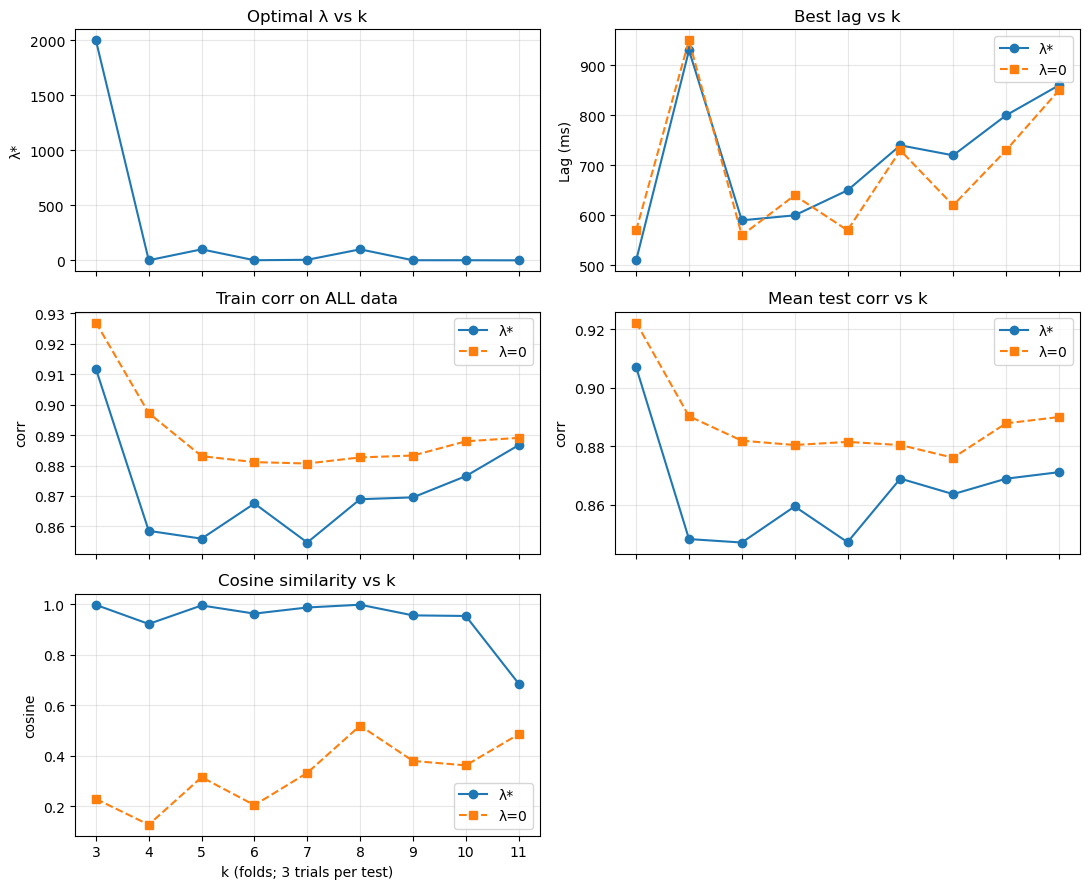

In [6]:
import pandas as pd
dfk = pd.DataFrame(rows).sort_values("k").reset_index(drop=True)
dfk.to_csv("dfkSLOW.csv", index=False)
dfk_norm = pd.DataFrame(rows_norm).sort_values("k").reset_index(drop=True)
dfk_norm.to_csv("dfkSLOWNorm.csv", index=False)
dfk = pd.read_csv("dfkSLOW.csv")

print("\n=== CV sweep (by k) ===")
with pd.option_context('display.max_rows', None, 'display.width', 140):
    print(dfk.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# ---- plots vs k
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 2, figsize=(11, 9), sharex=True)

axs[0,0].plot(dfk["k"], dfk["lam_star"], marker="o")
axs[0,0].set_title("Optimal λ vs k"); axs[0,0].set_ylabel("λ*"); axs[0,0].grid(alpha=.3)

axs[0,1].plot(dfk["k"], dfk["best_lag_ms_star"], marker="o", label="λ*")
axs[0,1].plot(dfk["k"], dfk["best_lag_ms_lam0"], marker="s", ls="--", label="λ=0")
axs[0,1].set_title("Best lag vs k"); axs[0,1].set_ylabel("Lag (ms)"); axs[0,1].legend(); axs[0,1].grid(alpha=.3)

axs[1,0].plot(dfk["k"], dfk["train_r_all_star"], marker="o", label="λ*")
axs[1,0].plot(dfk["k"], dfk["train_r_all_lam0"], marker="s", ls="--", label="λ=0")
axs[1,0].set_title("Train corr on ALL data"); axs[1,0].set_ylabel("corr"); axs[1,0].legend(); axs[1,0].grid(alpha=.3)

axs[1,1].plot(dfk["k"], dfk["mean_test_star"], marker="o", label="λ*")
axs[1,1].plot(dfk["k"], dfk["mean_test_lam0"], marker="s", ls="--", label="λ=0")
axs[1,1].set_title("Mean test corr vs k"); axs[1,1].set_ylabel("corr"); axs[1,1].legend(); axs[1,1].grid(alpha=.3)

axs[2,0].plot(dfk["k"], dfk["cos_star"], marker="o", label="λ*")
axs[2,0].plot(dfk["k"], dfk["cos_lam0"], marker="s", ls="--", label="λ=0")
axs[2,0].set_title("Cosine similarity vs k"); axs[2,0].set_ylabel("cosine"); axs[2,0].set_xlabel("k (folds; 3 trials per test)"); axs[2,0].legend(); axs[2,0].grid(alpha=.3)

axs[2,1].axis("off")
plt.tight_layout()
plt.show()



=== CV sweep (by k) ===
 k  lam_star  best_lag_ms_star  train_r_all_star  mean_test_star                                                                                                                                                                                                                                                                                    w_star  cos_star  best_lag_ms_lam0  train_r_all_lam0  mean_test_lam0                                                                                                                                                                                                            w_lam0  cos_lam0
 3      2000               510             0.912           0.900 [ 5.20462796e-03  8.59293632e-04  7.21279690e-03  7.33034200e-03\n -1.48177200e-03 -5.15401294e-05  5.44277959e-03  3.93638342e-03\n  5.03552370e-03  2.09203464e-03  7.63074182e-03  7.61781363e-03\n  5.03840714e-03  8.24949184e-03  6.45176069e-03  1.84462772e-03\n  5.63022979e-03]

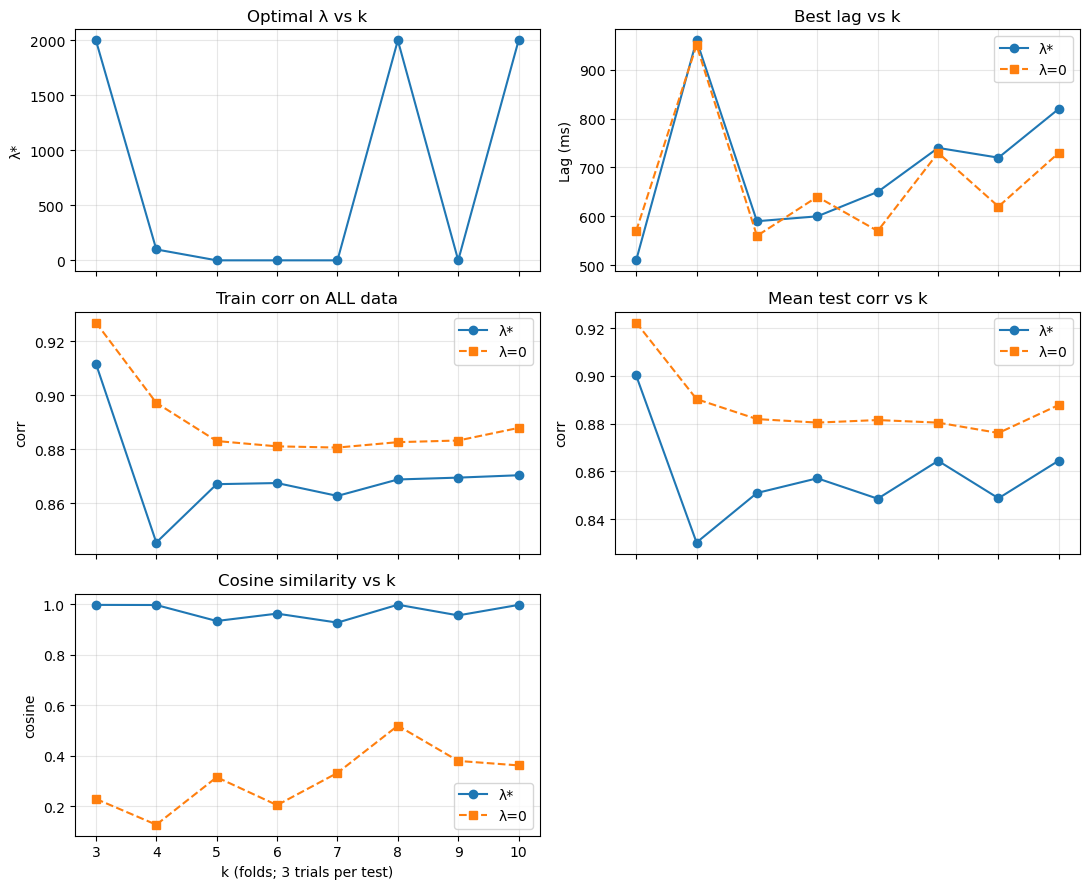

In [7]:
import pandas as pd
dfk = pd.read_csv("dfkSLOWNorm.csv")

print("\n=== CV sweep (by k) ===")
with pd.option_context('display.max_rows', None, 'display.width', 140):
    print(dfk.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# ---- plots vs k
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 2, figsize=(11, 9), sharex=True)

axs[0,0].plot(dfk["k"], dfk["lam_star"], marker="o")
axs[0,0].set_title("Optimal λ vs k"); axs[0,0].set_ylabel("λ*"); axs[0,0].grid(alpha=.3)

axs[0,1].plot(dfk["k"], dfk["best_lag_ms_star"], marker="o", label="λ*")
axs[0,1].plot(dfk["k"], dfk["best_lag_ms_lam0"], marker="s", ls="--", label="λ=0")
axs[0,1].set_title("Best lag vs k"); axs[0,1].set_ylabel("Lag (ms)"); axs[0,1].legend(); axs[0,1].grid(alpha=.3)

axs[1,0].plot(dfk["k"], dfk["train_r_all_star"], marker="o", label="λ*")
axs[1,0].plot(dfk["k"], dfk["train_r_all_lam0"], marker="s", ls="--", label="λ=0")
axs[1,0].set_title("Train corr on ALL data"); axs[1,0].set_ylabel("corr"); axs[1,0].legend(); axs[1,0].grid(alpha=.3)

axs[1,1].plot(dfk["k"], dfk["mean_test_star"], marker="o", label="λ*")
axs[1,1].plot(dfk["k"], dfk["mean_test_lam0"], marker="s", ls="--", label="λ=0")
axs[1,1].set_title("Mean test corr vs k"); axs[1,1].set_ylabel("corr"); axs[1,1].legend(); axs[1,1].grid(alpha=.3)

axs[2,0].plot(dfk["k"], dfk["cos_star"], marker="o", label="λ*")
axs[2,0].plot(dfk["k"], dfk["cos_lam0"], marker="s", ls="--", label="λ=0")
axs[2,0].set_title("Cosine similarity vs k"); axs[2,0].set_ylabel("cosine"); axs[2,0].set_xlabel("k (folds; 3 trials per test)"); axs[2,0].legend(); axs[2,0].grid(alpha=.3)

axs[2,1].axis("off")
plt.tight_layout()
plt.show()


In [ ]:
# ===================== SWEEP OVER k (uses the helpers you pasted) =====================
import numpy as np
import pandas as pd

if __name__ == "__main__":
    global RNG
    mode = "fast"
    RNG = np.random.default_rng(7) 
    
    rng_w0 = np.random.default_rng(42) # fixed seed for w0 only
    TRUE_LAG_MS = 700
    SHIFTS = candidate_lags_units(step_ms=10, max_ms=1500)
    W_SPREAD = 0.7
    EEEG_NOISE=0.35
    EEG_CROSSTALK=0.35
    PUPIL_NOISE=0.4

    LAMBDAS = [0, 0.1, 1, 5, 10, 100, 500, 900, 1000, 1100,1500, 2000]
    TRIM_MS = 200

    # Fix GT weights ONCE for comparable cosine similarity across k
    w0 = 1.0 + W_SPREAD * rng_w0.normal(size=N_CH)
    w0 = w0 / (np.linalg.norm(w0) or 1.0)

    # k in {4, 9, 12, 15, ..., 39}
    #ks = [4] + list(range(9, 20, 3))
    n_triplets = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 17, 20]

    rows = []
    for k in n_triplets:
        print(f"\n--- CV sweep at k={k} folds ---")
        # simulate 3*k trials (3 trials per test fold)
        sim_rng = np.random.default_rng(10_000 + k)
        trials_og = simulate_component_dataset(
            n_triplets=k, triplet_lengths_s=(26.0, 18.0, 10.0),
            pupil_lag_ms=TRUE_LAG_MS, w_true_fixed=w0, rng=sim_rng,
            pupil_extra='ar1', pupil_extra_scale=0.5,
            lag_jitter_ms=abs(TRUE_LAG_MS)*0.25,
            eeg_weight_drift=True, eeg_noise_sd=0.2
        )

        # ----- CV to choose λ* -----
        splits = triplet_splits_from_trials(trials_og, seed=7)
        trials_comp = split_components_all_trials(trials_og, fs=FS, low_fc=0.25, band=(0.4, 0.7))

        if mode == "slow":
            trials = [{'X': tr['X_slow'], 'y': tr['y_slow'], 'w_true': tr['w_true'], 'c': tr['c']} for tr in trials_comp]
        elif mode == "fast":
            trials = [{'X': tr['X_fast'], 'y': tr['y_fast'], 'w_true': tr['w_true'], 'c': tr['c']} for tr in trials_comp]
        else:
            trials = trials_og

        ordered_cv, final_fit = cross_validate_l2_and_lag(
            trials=trials,
            lambdas=LAMBDAS,
            candidate_shifts=SHIFTS,
            trim_ms=TRIM_MS,
            k_folds=k, seed=7,
            splits=splits
        )

        order_kx = pd.DataFrame(ordered_cv)
        order_kx.drop(columns=['per_fold'], inplace=True)
        order_kx.to_csv(f"orderFAST_k{k}.csv", index=False)

        best_cv = ordered_cv[0]  # highest mean test r (tie -> smaller λ)

        lam_star = final_fit["lambda"]
        best_shift_star = final_fit["best_shift"]
        lag_ms_star = int(best_shift_star) * 10
        w_star = final_fit["w"]
        train_r_all_star = final_fit["train_r_all"]
        mean_test_star = final_fit["cv_mean_test_r"]

        # cosine similarity at λ*
        num = float(np.dot(w0, w_star))
        den = (np.linalg.norm(w0) or 1.0) * (np.linalg.norm(w_star) or 1.0)
        cos_star = abs(num / den)

        # ===== λ = 0 (no reg) — DO NOT use CV to choose lag/weights =====
        # Choose lag+weights on ALL trials (search best lag over SHIFTS)
        best_r0_all, best_s0, w0_all = -np.inf, None, None
        for s in SHIFTS:
            w_s, r_all = fit_at_shift_lambda(trials, int(s), 0.0, TRIM_MS)
            if np.isfinite(r_all) and r_all > best_r0_all:
                best_r0_all, best_s0, w0_all = r_all, int(s), w_s
        lag_ms_zero = int(best_s0) * 10
        train_r_all_zero = float(best_r0_all)

        # For fairness, compute MEAN TEST corr for λ=0 by *evaluating* this fixed (lag,w) on the folds,
        # but not using any CV information to select them.
        rng = np.random.default_rng(7)
        splits = kfold_indices(len(trials), k, rng)
        test_rs_zero = []
        for tr_idx, te_idx in splits:
            te_set = [trials[i] for i in te_idx]
            r_te0 = evaluate_on_trials(te_set, best_s0, w0_all, TRIM_MS)
            test_rs_zero.append(r_te0)
        mean_test_zero = float(np.nanmean(test_rs_zero))

        # cosine similarity at λ=0
        num0 = float(np.dot(w0, w0_all))
        den0 = (np.linalg.norm(w0) or 1.0) * (np.linalg.norm(w0_all) or 1.0)
        cos_zero = abs(num0 / den0)

        rows.append({
            "k": k,
            "lam_star": lam_star,
            "best_lag_ms_star": lag_ms_star,
            "train_r_all_star": float(train_r_all_star),
            "mean_test_star": float(mean_test_star),
            "w_star": w_star,
            "cos_star": float(cos_star),
            "best_lag_ms_lam0": lag_ms_zero,
            "train_r_all_lam0": train_r_all_zero,
            "mean_test_lam0": mean_test_zero,
            "w_lam0": w0_all,
            "cos_lam0": float(cos_zero),
        })
        #dfk_temp = pd.DataFrame(rows).sort_values("k").reset_index(drop=True)
        #dfk_temp.to_csv("dfk6_temp.csv", index=False)

    # ---- results table
    dfk = pd.DataFrame(rows).sort_values("k").reset_index(drop=True)
    dfk.to_csv("dfkFAST.csv", index=False)

    print("\n=== CV sweep (by k) ===")
    with pd.option_context('display.max_rows', None, 'display.width', 140):
        print(dfk.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

    # ---- plots vs k
    import matplotlib.pyplot as plt

    fig, axs = plt.subplots(3, 2, figsize=(11, 9), sharex=True)

    axs[0,0].plot(dfk["k"], dfk["lam_star"], marker="o")
    axs[0,0].set_title("Optimal λ vs k"); axs[0,0].set_ylabel("λ*"); axs[0,0].grid(alpha=.3)

    axs[0,1].plot(dfk["k"], dfk["best_lag_ms_star"], marker="o", label="λ*")
    axs[0,1].plot(dfk["k"], dfk["best_lag_ms_lam0"], marker="s", ls="--", label="λ=0")
    axs[0,1].set_title("Best lag vs k"); axs[0,1].set_ylabel("Lag (ms)"); axs[0,1].legend(); axs[0,1].grid(alpha=.3)

    axs[1,0].plot(dfk["k"], dfk["train_r_all_star"], marker="o", label="λ*")
    axs[1,0].plot(dfk["k"], dfk["train_r_all_lam0"], marker="s", ls="--", label="λ=0")
    axs[1,0].set_title("Train corr on ALL data"); axs[1,0].set_ylabel("corr"); axs[1,0].legend(); axs[1,0].grid(alpha=.3)

    axs[1,1].plot(dfk["k"], dfk["mean_test_star"], marker="o", label="λ*")
    axs[1,1].plot(dfk["k"], dfk["mean_test_lam0"], marker="s", ls="--", label="λ=0")
    axs[1,1].set_title("Mean test corr vs k"); axs[1,1].set_ylabel("corr"); axs[1,1].legend(); axs[1,1].grid(alpha=.3)

    axs[2,0].plot(dfk["k"], dfk["cos_star"], marker="o", label="λ*")
    axs[2,0].plot(dfk["k"], dfk["cos_lam0"], marker="s", ls="--", label="λ=0")
    axs[2,0].set_title("Cosine similarity vs k"); axs[2,0].set_ylabel("cosine"); axs[2,0].set_xlabel("k (folds; 3 trials per test)"); axs[2,0].legend(); axs[2,0].grid(alpha=.3)

    axs[2,1].axis("off")
    plt.tight_layout()
    plt.show()



--- CV sweep at k=3 folds ---

--- CV sweep at k=4 folds ---

--- CV sweep at k=5 folds ---

--- CV sweep at k=6 folds ---

--- CV sweep at k=7 folds ---

--- CV sweep at k=8 folds ---

--- CV sweep at k=9 folds ---

--- CV sweep at k=10 folds ---

--- CV sweep at k=11 folds ---

--- CV sweep at k=12 folds ---

--- CV sweep at k=13 folds ---

--- CV sweep at k=15 folds ---

--- CV sweep at k=17 folds ---

--- CV sweep at k=20 folds ---

=== CV sweep (by k) ===
 k  lam_star  best_lag_ms_star  train_r_all_star  mean_test_star                                                                                                                                                                                                                                                                                                                                                                                                                             w_star  cos_star  best_lag_ms_lam0  train_r_all_lam0  mea

In [5]:
%matplotlib qt

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
n_triplets = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 17]


# Folder with your CSVs
folder = r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\simulated_check"

# The k values you mentioned
k_values = n_triplets
#k_values = [4]
# File name pattern: order_k{K}.csv
for k in k_values:
    path = os.path.join(folder, f"orderSLOW_k{k}.csv")
    if not os.path.isfile(path):
        print(f"[skip] File not found: {path}")
        continue

    df = pd.read_csv(path)

    # Basic validation
    required = {"lam", "mean_train_r", "mean_test_r"}
    missing = required - set(df.columns)
    if missing:
        print(f"[skip] {os.path.basename(path)} is missing columns: {missing}")
        continue

    # Ensure numeric & sort by lam
    for c in ["lam", "mean_train_r", "mean_test_r"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=["lam", "mean_train_r", "mean_test_r"]).sort_values("lam")

    # Plot for this k
    plt.figure()
    plt.plot(df["lam"], df["mean_train_r"], marker="o", label="mean_train_r")
    plt.plot(df["lam"], df["mean_test_r"], marker="s", label="mean_test_r")
    plt.xlabel("lam")
    plt.ylabel("r")
    plt.title(f"Train/Test r vs lam — k={k}")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()

    # Save and optionally show
    out_path = os.path.join(folder, f"order_k{k}.png")
    # plt.savefig(out_path, dpi=200)
    plt.show()  # uncomment if you want to pop up the window
    #plt.close()

    print(f"[ok] Saved: {out_path}")


[ok] Saved: C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\simulated_check\order_k3.png
[ok] Saved: C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\simulated_check\order_k4.png
[ok] Saved: C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\simulated_check\order_k5.png
[ok] Saved: C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\simulated_check\order_k6.png
[ok] Saved: C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\simulated_check\order_k7.png
[ok] Saved: C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\simulated_check\order_k8.png
[ok] Saved: C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\simulated_check\order_k9.png
[ok] Saved: C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\simulated_check\order_k10.png
[ok] Saved: C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\simulated_check\order_k11.png
[ok] Sav

In [11]:
Sxx = (X_tr.T @ X_tr) / len(X_tr)
evals = np.linalg.eigvalsh(Sxx)
gains = evals / (evals + lam)
print(f"cond(Sxx)={evals.max()/max(evals.min(),1e-12):.1e}, "
      f"median_gain={np.median(gains):.3f}, min_gain={gains[0]:.3f}")


NameError: name 'X_tr' is not defined